# KBOUND empirical data-quality audit and remediation record

**Forensic companion notebook · 27 August 2026**

This notebook reads the frozen forensic outputs and refreshes only bounded release metadata. It keeps two stages separate: the initial findings and the post-remediation control state. Historical defects remain visible even when code is fixed, because a fix cannot retroactively validate an affected result. Diagnostic corrections are never promoted as confirmatory evidence.


## tl;dr

The initial audit found five critical defects that could corrupt or manufacture natural routing evidence. The current tree now fails closed on Route-B orientation/task mismatch, duplicate/stale extraction, resume contamination, metric mismatch, infeasible calibration, incomplete runs, and non-finite JSON. Fourteen invalid derived artifacts were quarantined while raw sources were retained. These controls improve future-run integrity; they do **not** create a natural-shift win. Natural routing evidence remains **4.0/10**, iWildCam numerical/action claims remain withheld, and no verified unopened natural target exists. CIFAR-10-C Tent remains the strongest defensible empirical result.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

ROOT = Path.cwd().resolve()
if not (ROOT / "docs/research/kbound").exists():
    raise RuntimeError(f"Run from the repository root; cwd={ROOT}")

AUDIT_SCRIPT = ROOT / "docs/research/kbound/scripts/audit_empirical_data_quality_2026_08_27.py"
AUDIT_DIR = ROOT / "docs/research/kbound/audits/empirical_data_quality_2026_08_27"
subprocess.run([sys.executable, str(AUDIT_SCRIPT), "--out-dir", str(AUDIT_DIR), "--wording-only"], check=True)

summary = json.loads((AUDIT_DIR / "audit_summary.json").read_text())
findings = pd.read_csv(AUDIT_DIR / "findings.csv")
remediation = pd.read_csv(AUDIT_DIR / "remediation_status.csv")
profile = pd.read_csv(AUDIT_DIR / "canonical_dataset_profile.csv")
regret = pd.read_csv(AUDIT_DIR / "natural_policy_regret.csv")
opportunity = pd.read_csv(AUDIT_DIR / "natural_opportunity.csv")
checkpoints = pd.read_csv(AUDIT_DIR / "focused_officehome_checkpoints.csv")
scorecard = pd.read_csv(AUDIT_DIR / "reviewer_scorecard.csv")

display(Markdown(
    f"**Executed with:** `{Path(sys.executable).name}`  \n"
    f"**Canonical SHA-256:** `{summary['canonical']['canonical_sha256']}`  \n"
    f"**Source-manifest SHA-256:** `{summary['canonical']['source_manifest_sha256']}`"
))


{
  "out_dir": "docs/research/kbound/audits/empirical_data_quality_2026_08_27",
  "summary": {
    "defensible_natural_beats_both_win": false,
    "controlled_cifar10c_tent_remains_strong": true,
    "controlled_cifar10c_retrospective_six_contrast_holm_win": false,
    "can_guarantee_9_5_empirical_score": false,
    "code_hardening_retroactively_repairs_historical_results": false,
    "recommended_claim": "Strong controlled routing evidence; hardened natural-shift code is ready for sealed reruns, while existing natural evidence remains a transparent boundary/null result rather than a natural win."
  }
}


**Executed with:** `python`  
**Canonical SHA-256:** `ee64e858184cc9f67f4e596183b69880d59d64d267e22d3ba29c422afa609df9`  
**Source-manifest SHA-256:** `391983f4fa09d65c256ab8c620fea772866b652c219dad0c36574ce38c740482`

## Context & Methods

The intended candidate grain is dataset × checkpoint/model seed × stream seed × domain/location/backbone × split × composition × regime × aggressiveness × candidate. A route row removes the candidate dimension. Inference units, repeated condition evaluations, paired twins, and stream seeds are audited separately.

Checks include strict JSON parsing (including decoded overflow), SHA-256 and byte-count verification, recorded row counts, within-file key uniqueness, `B = adapted − frozen`, score/range checks, action-count and regret reconciliation, route-estimator orientation, resume-role isolation, extraction lineage, calibration feasibility, official metric parity, and release seals. Each initial finding is joined one-to-one to a remediation status, release disposition, verification path, and remaining requirement. The corrected iWildCam replay remains diagnostic even when executed in the pinned reconciliation runtime because it is not a sealed official-metric rerun over a frozen population.


In [2]:
grain = pd.DataFrame(
    [{"object": key, "intended_grain_or_rule": value} for key, value in summary["intended_grain"].items()]
)
display(grain)

assert summary["canonical"]["source_manifest_hash_matches_canonical"]
assert summary["canonical"]["aggregate_score_checks"]["problem_count"] == 0
assert summary["bottom_line"]["defensible_natural_beats_both_win"] is False
assert summary["bottom_line"]["controlled_cifar10c_retrospective_six_contrast_holm_win"] is False
assert summary["bottom_line"]["code_hardening_retroactively_repairs_historical_results"] is False
assert len(remediation) == len(findings) == 15
assert set(remediation["rank"]) == set(findings["rank"]) == set(range(1, 16))
assert summary["audit_stages"]["post_remediation"]["natural_shift_routing_evidence_score_out_of_10"] == 4.0
print("Core audit and remediation assertions passed.")


,object,intended_grain_or_rule
0,candidate_record,dataset x checkpoint/model_seed x stream_seed ...
1,inference_unit_warning,"inference units, condition evaluations, repeat..."
2,route_record,same condition key without candidate


Core audit and remediation assertions passed.


## Data

The hash-locked analytical base is `experiments/kbound/results/reconciled_panels_v1`. It contains 106 source-manifest entries, including 101 record files and five summary artifacts. Internal reconciliation establishes integrity, not universal claim eligibility: iWildCam remains explicitly withheld under its archived metric contract. The audit also reads archived `result_*.json` files only to identify historical pipeline defects; those artifacts are not silently promoted into release estimates.


In [3]:
bundle = summary["canonical"]["bundle"]
integrity = pd.DataFrame([
    {"check": "Original source hash failures", "value": bundle["original_hash_failures"]},
    {"check": "Compact hash failures", "value": bundle["compact_hash_failures"]},
    {"check": "Recorded row-count failures", "value": bundle["row_count_failures"]},
    {"check": "Exact duplicate records within a compact file", "value": bundle["exact_duplicate_records_within_file"]},
    {"check": "Duplicate intended keys within a compact file", "value": bundle["duplicate_dimension_keys_within_file"]},
    {"check": "Benefit identity failures", "value": bundle["benefit_identity_failures"]},
    {"check": "Core non-finite values", "value": bundle["core_nonfinite_values"]},
    {"check": "Aggregate score nodes checked", "value": summary["canonical"]["aggregate_score_checks"]["score_nodes_checked"]},
    {"check": "Aggregate score problems", "value": summary["canonical"]["aggregate_score_checks"]["problem_count"]},
])
display(integrity)
display(profile.sort_values("records", ascending=False).reset_index(drop=True))

print(f"Missing explicit metric: {bundle['missing_metric_records']:,}/{bundle['records_total']:,} "
      f"({bundle['missing_metric_rate']:.2%})")
print(f"Rows whose file metadata lacks dataset: {bundle['records_missing_metadata_dataset']:,}/{bundle['records_total']:,} "
      f"({bundle['records_missing_metadata_dataset_rate']:.2%})")


,check,value
0,Original source hash failures,0
1,Compact hash failures,0
2,Recorded row-count failures,0
3,Exact duplicate records within a compact file,0
4,Duplicate intended keys within a compact file,0
5,Benefit identity failures,0
6,Core non-finite values,0
7,Aggregate score nodes checked,117
8,Aggregate score problems,0


,dataset,source_files,record_files,records,missing_metric_records,missing_metadata_dataset_records,strict_json_failures
0,cifar10c,15,15,6480,6480,6480,0
1,rxrx1,3,3,2160,2160,0,0
2,officehome,4,4,1102,0,0,0
3,iwildcam,2,1,864,0,0,0
4,camelyon17_ood,1,1,540,540,540,0
5,imagenetr,40,40,480,480,480,0
6,imagenetc,15,15,405,405,405,0
7,camelyon17_b_v2,9,9,324,324,324,0
8,pacs,12,8,144,144,0,0
9,cifar101,5,5,120,120,120,0


Missing explicit metric: 10,653/12,619 (84.42%)
Rows whose file metadata lacks dataset: 8,349/12,619 (66.16%)


## Results

The canonical bundle passes its internal integrity checks. That does not validate every algorithm or historical artifact. The table below preserves the initial failures and then shows the present control state. “Implemented” means a new run fails closed under the repaired contract; it never means the old result was repaired.


In [4]:
severity_order = pd.CategoricalDtype(["Critical", "High", "Medium", "Low"], ordered=True)
findings_view = findings.copy()
findings_view["severity"] = findings_view["severity"].astype(severity_order)
display(findings_view[[
    "rank", "severity", "category", "finding", "remediation_status", "release_disposition"
]].sort_values(["severity", "rank"]).reset_index(drop=True))

display(remediation[[
    "rank", "remediation_status", "remediation_action", "remaining_requirement"
]].sort_values("rank").reset_index(drop=True))

route = summary["route_b_archive"]
route_table = pd.DataFrame([
    {"measure": "Archived route cells", "count": route["route_cells"], "denominator": route["route_cells"]},
    {"measure": "b_hat / b_tilde sign-disagreement cells", "count": route["b_hat_b_tilde_sign_disagreement_cells"], "denominator": route["route_cells"]},
    {"measure": "b_hat outside [-1,1] cells", "count": route["b_hat_outside_unit_interval_cells"], "denominator": route["route_cells"]},
    {"measure": "ADAPT cells", "count": route["adapt_cells"], "denominator": route["route_cells"]},
    {"measure": "ADAPT cells with negative spectral anchor", "count": route["adapt_negative_anchor_cells"], "denominator": route["adapt_cells"]},
    {"measure": "ADAPT cells with strictly harmful realized benefit", "count": route["adapt_negative_realized_benefit_cells"], "denominator": route["adapt_cells"]},
])
route_table["rate"] = route_table["count"] / route_table["denominator"]
display(route_table)


,rank,severity,category,finding,remediation_status,release_disposition
0,1,Critical,Route-B estimator,Arbitrary-sign b_hat drives routing although b...,CONTROL_IMPLEMENTED_HISTORICAL_ROUTE_WITHHELD,Historical Route-B decisions are non-promotabl...
1,2,Critical,Theory/task mismatch,The binary correctness-agreement identity is a...,CONTROL_IMPLEMENTED_HISTORICAL_ROUTE_WITHHELD,No multiclass Route-B action or score from the...
2,3,Critical,Duplicate leakage,Office-Home five-seed zero-regret aggregate ha...,QUARANTINED_AND_CONTROL_IMPLEMENTED,QUARANTINED_NO_RELEASE_USE
3,4,Critical,Stale lineage,An iWildCam aggregate was emitted from stale s...,QUARANTINED_AND_CONTROL_IMPLEMENTED,QUARANTINED_NO_RELEASE_USE
4,5,Critical,Resume contamination,A declared Office-Home target-test result cont...,CONTROL_IMPLEMENTED_HISTORICAL_ARTIFACT_WITHHELD,The contaminated historical target-test artifa...
5,6,High,Metric parity,iWildCam sklearn macro-F1 includes prediction-...,CONTROL_IMPLEMENTED_RERUN_REQUIRED,WITHHELD_INVALID_METRIC_CONTRACT_DIAGNOSTIC_ONLY
6,7,High,Target-label leakage,Broad multiseed extraction can combine validat...,CONTROL_IMPLEMENTED_DEVELOPMENT_DIAGNOSTIC_ONLY,DEVELOPMENT_DIAGNOSTIC_ONLY_NO_HELDOUT_PROMOTION
7,8,High,Structural infeasibility,Single-adapter natural runners have M=2 while ...,CONTROL_IMPLEMENTED_HISTORICAL_RESULT_WITHHELD,Historical structurally infeasible routing res...
8,9,High,Error handling,Route ERROR and incomplete cells can be scored...,CONTROL_IMPLEMENTED_RERUN_REQUIRED,"Only complete, failure-free manifests may feed..."
9,10,High,PACS denominator,The draft calls 108 twin-pairs condition cells...,MANUSCRIPT_CORRECTED,Corrected denominator language is eligible for...


,rank,remediation_status,remediation_action,remaining_requirement
0,1,CONTROL_IMPLEMENTED_HISTORICAL_ROUTE_WITHHELD,Route B now uses a bounded anchor-oriented med...,Run the sealed task-compatible protocol and ve...
1,2,CONTROL_IMPLEMENTED_HISTORICAL_ROUTE_WITHHELD,"Route B now requires binary classification, ex...",Use Route A or a separately derived and valida...
2,3,QUARANTINED_AND_CONTROL_IMPLEMENTED,Duplicate scientific keys now hard-fail before...,Regenerate only from one canonical run per sci...
3,4,QUARANTINED_AND_CONTROL_IMPLEMENTED,Extraction now writes to a fresh atomic stage ...,A fresh official-metric source run is required...
4,5,CONTROL_IMPLEMENTED_HISTORICAL_ARTIFACT_WITHHELD,Natural runners now require runner-specific se...,Rerun target-test in a fresh directory with th...
5,6,CONTROL_IMPLEMENTED_RERUN_REQUIRED,The iWildCam scorer now matches WILDS label-pr...,Run the official metric prospectively in the p...
6,7,CONTROL_IMPLEMENTED_DEVELOPMENT_DIAGNOSTIC_ONLY,"The extractor prohibits target-test labels, se...",Obtain independent checkpoints and a sealed he...
7,8,CONTROL_IMPLEMENTED_HISTORICAL_RESULT_WITHHELD,Exact-rank infeasibility now serializes as nul...,Supply a predeclared calibration pool and cand...
8,9,CONTROL_IMPLEMENTED_RERUN_REQUIRED,"ERROR/UNSUPPORTED routes are unscorable, stric...",Rerun any historical panel whose original mani...
9,10,MANUSCRIPT_CORRECTED,The manuscript now distinguishes 216 decision ...,Preserve the three denominators in every gener...


,measure,count,denominator,rate
0,Archived route cells,2892,2892,1.000000
1,b_hat / b_tilde sign-disagreement cells,2534,2892,0.876210
2,"b_hat outside [-1,1] cells",1685,2892,0.582642
3,ADAPT cells,138,2892,0.047718
4,ADAPT cells with negative spectral anchor,138,138,1.000000
5,ADAPT cells with strictly harmful realized ben...,105,138,0.760870


In [5]:
lineage = summary["multiseed_lineage"]
resume = summary["resume_contamination"]
metric = summary["iwild_metric"]

diagnostics = pd.DataFrame([
    {"diagnostic": "Office-Home invalid extracted rows", "value": lineage["officehome"]["rows"], "interpretation": "Historical evidence retained in quarantine manifest"},
    {"diagnostic": "Office-Home unique seed-condition keys", "value": lineage["officehome"]["unique_seed_condition_keys"], "interpretation": "90 unique among 180 historical rows"},
    {"diagnostic": "Office-Home reported oracle-action matches", "value": lineage["officehome"]["oracle_action_matches"], "interpretation": "Invalid perfect result under duplicate leakage"},
    {"diagnostic": "Non-test rows in target-test resume artifact", "value": resume["non_test_conditions_in_target_test_artifact"], "interpretation": f"{resume['non_test_fraction']:.1%} of artifact"},
    {"diagnostic": "iWild full-test benefit sign flips after official metric correction", "value": metric["full_test_864_record_diagnostic"]["benefit_sign_flips"], "interpretation": "60/864 candidate cells"},
    {"diagnostic": "Invalid derived artifacts quarantined", "value": summary["audit_stages"]["post_remediation"]["invalid_derived_artifacts_quarantined"], "interpretation": "Raw source runs retained"},
    {"diagnostic": "Release checksum mismatches", "value": summary["release_checksums"]["status_counts"].get("mismatch", 0), "interpretation": "Final reseal remains a release-stage task"},
])
display(diagnostics)

replay = metric["corrected_transfer_replay"]
display(pd.DataFrame([{
    "diagnostic_replay": "iWild official-metric correction",
    "epsilon": replay.get("epsilon"),
    "adapt": replay.get("action_counts", {}).get("adapt"),
    "freeze": replay.get("action_counts", {}).get("freeze"),
    "abstain": replay.get("action_counts", {}).get("abstain"),
    "regret_kga": replay.get("regret", {}).get("kga"),
    "regret_best_fixed": min(replay.get("regret", {"x": np.nan}).values()),
    "beats_both": replay.get("point_beats_both"),
    "status": replay.get("status"),
}]))


,diagnostic,value,interpretation
0,Office-Home invalid extracted rows,180,Historical evidence retained in quarantine man...
1,Office-Home unique seed-condition keys,90,90 unique among 180 historical rows
2,Office-Home reported oracle-action matches,180,Invalid perfect result under duplicate leakage
3,Non-test rows in target-test resume artifact,24,57.1% of artifact
4,iWild full-test benefit sign flips after offic...,60,60/864 candidate cells
5,Invalid derived artifacts quarantined,14,Raw source runs retained
6,Release checksum mismatches,5,Final reseal remains a release-stage task


,diagnostic_replay,epsilon,adapt,freeze,abstain,regret_kga,regret_best_fixed,beats_both,status
0,iWild official-metric correction,0.121853,0,4,68,0.005511,0.005511,False,diagnostic_only_runtime_differs_from_pinned_re...


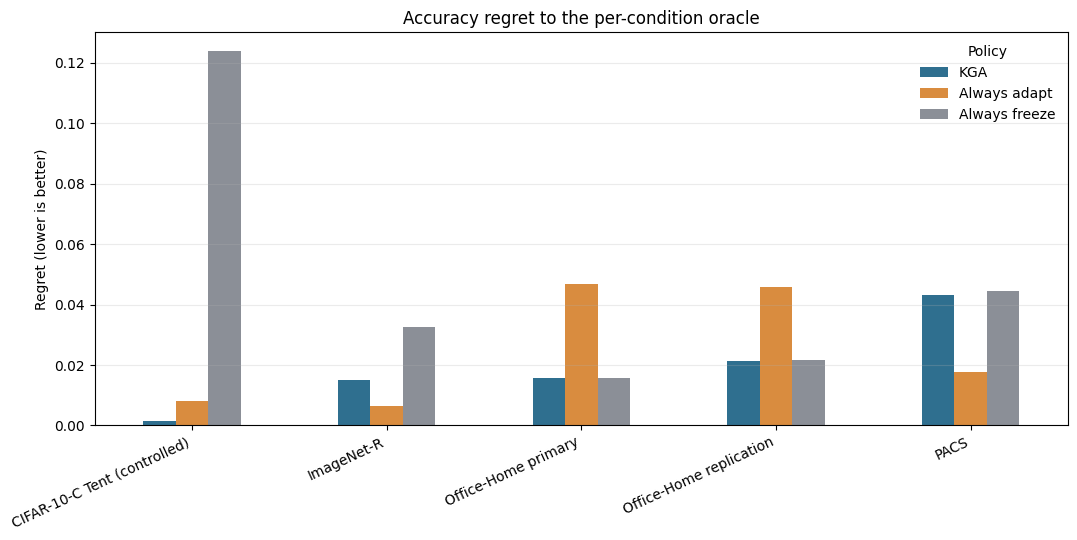

,panel,n,helpful,harmful,tied,adapt_count,freeze_count,abstain_count,regret_kga,regret_best_fixed,point_beats_both,claim_scope,numeric_release_eligible
0,Camelyon17 OOD,18,18,0,0,18,0,0,0.000000,0.000000,False,opened_target_one_sided_diagnostic,True
1,ImageNet-R,480,383,92,5,165,29,286,0.014969,0.006359,False,opened_target_negative_diagnostic,True
2,Office-Home primary,35,23,12,0,0,11,24,0.015824,0.015824,False,opened_target_null_diagnostic,True
3,Office-Home replication,54,35,19,0,1,14,39,0.021510,0.021724,True,opened_target_stream_seed_diagnostic,True
4,RxRx1,60,0,60,0,0,60,0,0.000000,0.000000,False,opened_target_one_sided_diagnostic,True
5,iWildCam H-v2,72,9,63,0,0,21,51,0.004102,0.004102,False,withheld_invalid_archived_metric_contract_hist...,False


In [6]:
# Same-metric view: accuracy regret only. Compare policies within a panel; protocols and units differ.
plot_rows = regret[(regret["metric"] == "accuracy") & regret["panel"].isin([
    "CIFAR-10-C Tent (controlled)",
    "Office-Home primary",
    "Office-Home replication",
    "ImageNet-R",
    "PACS",
])]
pivot = plot_rows.pivot(index="panel", columns="policy", values="regret")
pivot = pivot[["KGA", "Always adapt", "Always freeze"]]

ax = pivot.plot(kind="bar", figsize=(11, 5.5), color=["#2f6f8f", "#d98c3f", "#8b8f97"])
ax.set_title("Accuracy regret to the per-condition oracle")
ax.set_ylabel("Regret (lower is better)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Policy", frameon=False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(opportunity.sort_values("panel").reset_index(drop=True))


In [7]:
display(checkpoints)
focused = summary["focused_officehome"]
sar_gain = checkpoints["sar_minus_freeze"].to_numpy(float)
oracle_edge = checkpoints["oracle_minus_sar"].to_numpy(float)

def t_interval(values, confidence=0.95):
    values = np.asarray(values, float)
    mean = values.mean()
    half = stats.t.ppf((1 + confidence) / 2, len(values) - 1) * stats.sem(values)
    return mean, mean - half, mean + half

sar_ci = t_interval(sar_gain)
oracle_ci = t_interval(oracle_edge)
focused_view = pd.DataFrame([
    {"contrast": "SAR minus freeze", "mean": sar_ci[0], "ci95_low": sar_ci[1], "ci95_high": sar_ci[2]},
    {"contrast": "Oracle minus SAR", "mean": oracle_ci[0], "ci95_low": oracle_ci[1], "ci95_high": oracle_ci[2]},
])
display(focused_view)

assert focused["route_action_counts"] == {"ABSTAIN": 15}
assert focused["single_candidate_route_feasible"] is False
assert focused["tau_min"] > focused["locked_tau_star"]
print(f"Strict-JSON failures: {focused['strict_json_files_failed']}/5 files; "
      f"literal Infinity values: {focused['literal_infinity_values']}")


,model_seed,checkpoint_sha256,conditions,mean_freeze_accuracy,mean_sar_accuracy,mean_oracle_accuracy,sar_minus_freeze,oracle_minus_sar,eata_sar_exact_prediction_cells
0,0,5974c30af81b3d0af21c93edbeb014297d2cbae5b0ecd7...,3,0.575385,0.593846,0.593846,0.018462,0.000000,2
1,1,8bbae69dbaeb9151a54904f9c2ec5c80f3a8211c4a5624...,3,0.581538,0.592821,0.602051,0.011282,0.009231,2
2,2,bddd1bc039c6c6c64ba2aa279afd862564e460baa3993b...,3,0.550769,0.570256,0.574359,0.019487,0.004103,2
3,3,4d4331fdfd9630876ba866bf731dea106dbd4aa4f1d502...,3,0.551795,0.580513,0.580513,0.028718,0.000000,2
4,4,2dee9c8582d7e33448f7aa8636e74607e5bb321fcec0aa...,3,0.595897,0.619487,0.619487,0.023590,0.000000,2


,contrast,mean,ci95_low,ci95_high
0,SAR minus freeze,0.020308,0.012284,0.028332
1,Oracle minus SAR,0.002667,-0.002395,0.007729


Strict-JSON failures: 5/5 files; literal Infinity values: 57


In [8]:
display(scorecard)
post = summary["audit_stages"]["post_remediation"]
print(
    "Post-remediation overall score:", post["overall_score_status"],
    "| natural evidence remains", post["natural_shift_routing_evidence_score_out_of_10"], "/10"
)


,stage,dimension,score_out_of_10,score_status,basis
0,current_evidence,Canonical bundle integrity,9.5,SCORED,"106/106 source and compact hashes pass; 12,619..."
1,current_evidence,Controlled CIFAR-10-C evidence,NaN,NOT_RESCORED_AFTER_INFERENCE_CORRECTION,Tent has a beats-both point estimate and posit...
2,current_evidence,Natural-shift routing evidence,4.0,UNCHANGED_AFTER_CODE_REMEDIATION,No defensible natural beats-both win exists. H...
3,initial_audit,Estimator/task validity (pre-remediation),4.0,HISTORICAL_BASELINE,The initial audit found arbitrary Route-B orie...
4,initial_audit,Provenance and reproducibility (pre-remediation),5.5,HISTORICAL_BASELINE,"The initial audit found resume contamination, ..."
5,initial_audit,Initial empirical readiness (pre-remediation),5.8,HISTORICAL_BASELINE,Senior-reviewer judgment at initial diagnosis;...
6,post_remediation,Post-remediation overall empirical readiness,NaN,NOT_RESCORED_PENDING_PROSPECTIVE_EVIDENCE,A new overall score is withheld until hardened...


Post-remediation overall score: WITHHELD_PENDING_SEALED_PROSPECTIVE_EVIDENCE | natural evidence remains 4.0 /10


## Takeaways

1. **Quarantine is complete for the invalid derived set.** Fourteen duplicate-leaked, stale-lineage, or downstream presentation artifacts are outside the release tree; raw source runs and hashes are retained for audit.
2. **The repaired paths now fail closed.** Scientific-config resume hashes, official metric parity, strict error/completeness ledgers, candidate rank and feasibility checks, atomic lineage, strict JSON, and explicit inference-unit fields protect fresh runs.
3. **Historical evidence remains historical.** Old Route-B, contaminated resume, iWildCam metric, and infeasible-calibration results stay non-promotable until rerun under the new contract.
4. **No natural win is claimed.** All current natural targets are opened, so they support only transparent diagnostic, null, or boundary statements. The natural-shift evidence score remains **4.0/10**.
5. **Preserve the bounded controlled result.** CIFAR-10-C Tent has a beats-both point estimate and positive ordinary six-family intervals, but both preregistered six-comparison Holm p-values are 0.09375. It is not a cluster-robust or confirmatory win.
6. **A new overall score is withheld.** The initial **5.8/10** readiness judgment is retained as a historical baseline, not relabeled as current. A 9–9.5 rigor score would require complete hardened reruns, a final checksum seal, and a genuinely new or hidden-label natural evaluation.
